# 🐍 Snake Classifier v2 — Target 90%+
**EfficientNetV2-L + TTA + Mixup + Focal Loss | Kaggle T4**

## 0. Install Packages

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
    'timm', 'torchmetrics', 'grad-cam', 'matplotlib',
    'seaborn', 'pillow', 'tqdm', 'scikit-learn'])

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 52.7 MB/s eta 0:00:00


0

## 1. Imports & Seeds

In [2]:
import os, random, json, warnings
from pathlib import Path
from collections import Counter
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
import timm

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

print('Imports done ✓')

Device : cuda
GPU    : Tesla T4
Imports done ✓


## 2. Paths

In [3]:
INPUT_ROOT = Path('/kaggle/input/datasets/abdullahkhaliq14/snakes-datasets')
OUTPUT_DIR = Path('/kaggle/working')
MODEL_DIR  = OUTPUT_DIR / 'models'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
print('Paths ready ✓')

Paths ready ✓


## 3. Discover Classes

In [4]:
def _is_image(p):
    return p.suffix.lower() in {'.jpg','.jpeg','.png','.bmp','.webp','.gif','.tiff','.tif'}

class_to_images = {}
for zip_folder in sorted(INPUT_ROOT.iterdir()):
    if not zip_folder.is_dir(): continue
    for class_dir in sorted(zip_folder.iterdir()):
        if not class_dir.is_dir(): continue
        cls = (class_dir.name.lower()
               .replace("'","").replace(',','').replace('-','_').replace(' ','_').strip('_'))
        imgs = [p for p in class_dir.rglob('*') if _is_image(p)]
        if imgs:
            class_to_images.setdefault(cls, []).extend(imgs)

class_to_images = {k: list(set(v)) for k,v in class_to_images.items()}
class_counts = {k: len(v) for k,v in class_to_images.items()}
classes      = sorted(class_counts.keys())
NUM_CLASSES  = len(classes)
CLASS_TO_IDX = {c:i for i,c in enumerate(classes)}
IDX_TO_CLASS = {i:c for c,i in CLASS_TO_IDX.items()}

print(f'Classes: {NUM_CLASSES}  |  Total images: {sum(class_counts.values()):,}')
for c in classes:
    print(f'  {c:<50s} {class_counts[c]:>4d}')

Classes: 25  |  Total images: 21,292
  banded_kukri_snake                                  915
  black_headed_royal_snake                            529
  blunt_nosed_viper                                   509
  brahminy_blind_snake                               2405
  buff_striped_keelback                              1963
  caspian_cobra                                       550
  checkered_keelback                                 1225
  common_cat_snake                                    578
  common_krait                                       1744
  common_sand_boa                                    1288
  common_wolf_snake                                   915
  diadem_royal_or_mouse_eater                         532
  diadem_snake_or_royal_snake                         434
  glossy_bellied_racer                                575
  himalayan_pit_viper                                 735
  indian_cobra                                        406
  indian_wolf_snake                

## 4. Split

In [5]:
all_paths, all_labels = [], []
for cls in classes:
    all_paths  += class_to_images[cls]
    all_labels += [CLASS_TO_IDX[cls]] * len(class_to_images[cls])

all_paths  = np.array(all_paths,  dtype=object)
all_labels = np.array(all_labels, dtype=np.int64)

X_train, X_tmp, y_train, y_tmp = train_test_split(
    all_paths, all_labels, test_size=0.30, stratify=all_labels, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED)

print(f'Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}')

Train: 14,904  Val: 3,194  Test: 3,194


## 5. Transforms — Fixed RandomErasing Order

In [6]:
IMG_SIZE    = 384
BATCH_SIZE  = 16
NUM_WORKERS = 2

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

# FIX: RandomErasing MUST come after ToTensor() because it needs a tensor, not PIL image
train_tf = T.Compose([
    T.Resize((IMG_SIZE + 48, IMG_SIZE + 48)),
    T.RandomCrop(IMG_SIZE),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(p=0.3),
    T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.15),
    T.RandomRotation(45),
    T.RandomGrayscale(p=0.05),
    T.RandomPerspective(distortion_scale=0.2, p=0.3),
    T.ToTensor(),                                      # <-- PIL transforms end here
    T.Normalize(MEAN, STD),
    T.RandomErasing(p=0.2, scale=(0.02, 0.15)),        # <-- tensor-only transform AFTER Normalize
])

val_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

# TTA transforms (5 views averaged at test time)
tta_tfs = [
    T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)),                          T.ToTensor(), T.Normalize(MEAN, STD)]),
    T.Compose([T.Resize((IMG_SIZE+32, IMG_SIZE+32)), T.CenterCrop(IMG_SIZE), T.ToTensor(), T.Normalize(MEAN, STD)]),
    T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)), T.RandomHorizontalFlip(p=1.0), T.ToTensor(), T.Normalize(MEAN, STD)]),
    T.Compose([T.Resize((IMG_SIZE+32, IMG_SIZE+32)), T.RandomCrop(IMG_SIZE),  T.ToTensor(), T.Normalize(MEAN, STD)]),
    T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)), T.RandomRotation(10),           T.ToTensor(), T.Normalize(MEAN, STD)]),
]

print(f'Image size : {IMG_SIZE}x{IMG_SIZE}')
print(f'Batch size : {BATCH_SIZE}')
print('Transforms ready ✓')

Image size : 384x384
Batch size : 16
Transforms ready ✓


## 6. Dataset & DataLoaders

In [7]:
class SnakeDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, int(self.labels[idx])


train_ds = SnakeDataset(X_train, y_train, train_tf)
val_ds   = SnakeDataset(X_val,   y_val,   val_tf)
test_ds  = SnakeDataset(X_test,  y_test,  val_tf)

# Weighted sampler to balance class imbalance
label_counts = Counter(y_train.tolist())
weights = [1.0 / label_counts[int(l)] for l in y_train]
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                      num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE*2, shuffle=False,
                      num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE*2, shuffle=False,
                      num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)

print(f'Train batches: {len(train_dl)}  Val batches: {len(val_dl)} ✓')

Train batches: 932  Val batches: 100 ✓


## 7. Mixup Helper

In [8]:
def mixup_data(x, y, alpha=0.4):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    index = torch.randperm(x.size(0)).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index]
    return mixed_x, y, y[index], lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

print('Mixup ready ✓')

Mixup ready ✓


## 8. Build Model — EfficientNetV2-L

In [9]:
MODEL_NAME = 'tf_efficientnetv2_l'

def build_model(num_classes, model_name=MODEL_NAME, freeze_backbone=True):
    model = timm.create_model(
        model_name,
        pretrained=True,
        num_classes=num_classes,
        drop_rate=0.3,
        drop_path_rate=0.2,
    )
    if freeze_backbone:
        for name, param in model.named_parameters():
            if 'classifier' not in name:
                param.requires_grad = False
    return model

model     = build_model(NUM_CLASSES, freeze_backbone=True).to(DEVICE)
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model         : {MODEL_NAME}')
print(f'Total params  : {total:,}')
print(f'Trainable Ph1 : {trainable:,}')

model.safetensors:   0%|          | 0.00/476M [00:00<?, ?B/s]

Model         : tf_efficientnetv2_l
Total params  : 117,266,297
Trainable Ph1 : 32,025


## 9. Focal Loss + Training Utilities

In [10]:
class FocalLoss(nn.Module):
    """Focal loss with label smoothing. Penalises hard examples more."""
    def __init__(self, gamma=2.0, label_smoothing=0.1, num_classes=25):
        super().__init__()
        self.gamma = gamma
        self.ls    = label_smoothing
        self.nc    = num_classes

    def forward(self, logits, targets):
        with torch.no_grad():
            smooth = torch.full_like(logits, self.ls / (self.nc - 1))
            smooth.scatter_(1, targets.unsqueeze(1), 1.0 - self.ls)
        log_p = F.log_softmax(logits, dim=1)
        ce    = -(smooth * log_p).sum(dim=1)
        p     = torch.exp(-ce)
        return (((1 - p) ** self.gamma) * ce).mean()


def train_one_epoch(model, loader, criterion, optimizer, scaler, use_mixup=False):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in tqdm(loader, leave=False, desc='  train'):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        if use_mixup:
            imgs, y_a, y_b, lam = mixup_data(imgs, labels, alpha=0.4)
        with torch.cuda.amp.autocast():
            out = model(imgs)
            loss = mixup_criterion(criterion, out, y_a, y_b, lam) if use_mixup else criterion(out, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * imgs.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels_out = [], []
    for imgs, labels in tqdm(loader, leave=False, desc='  eval'):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        with torch.cuda.amp.autocast():
            out  = model(imgs)
            loss = criterion(out, labels)
        total_loss     += loss.item() * imgs.size(0)
        preds           = out.argmax(1)
        correct        += (preds == labels).sum().item()
        total          += imgs.size(0)
        all_preds      += preds.cpu().tolist()
        all_labels_out += labels.cpu().tolist()
    return total_loss / total, correct / total, all_preds, all_labels_out


@torch.no_grad()
def evaluate_tta(model, paths, labels_arr):
    """Average predictions across 5 TTA views for higher accuracy."""
    model.eval()
    all_probs = []
    for tf in tta_tfs:
        ds = SnakeDataset(paths, labels_arr, tf)
        dl = DataLoader(ds, batch_size=BATCH_SIZE*2, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)
        probs_this = []
        for imgs, _ in tqdm(dl, leave=False, desc='  TTA'):
            imgs = imgs.to(DEVICE)
            with torch.cuda.amp.autocast():
                probs_this.append(torch.softmax(model(imgs), dim=1).cpu())
        all_probs.append(torch.cat(probs_this, dim=0))
    avg_probs = torch.stack(all_probs).mean(0)
    preds  = avg_probs.argmax(1).tolist()
    acc    = sum(p == int(l) for p, l in zip(preds, labels_arr)) / len(preds)
    return acc, preds


def plot_curves(log, title='Training curves'):
    df = pd.DataFrame(log)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(df['epoch'], df['train_loss'], label='Train loss')
    axes[0].plot(df['epoch'], df['val_loss'],   label='Val loss')
    axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')
    axes[1].plot(df['epoch'], df['train_acc'],  label='Train acc')
    axes[1].plot(df['epoch'], df['val_acc'],    label='Val acc')
    axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].set_xlabel('Epoch')
    plt.suptitle(title); plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"curves_{title.replace(' ','_')}.png", dpi=130)
    plt.show()

print('Focal Loss + training utilities ready ✓')

Focal Loss + training utilities ready ✓


## 10. Phase 1 — Frozen Backbone

=== PHASE 1 — Frozen backbone ===


  train:   0%|          | 0/932 [00:00<?, ?it/s]

  eval:   0%|          | 0/100 [00:00<?, ?it/s]

  Ep 1/5  train_acc=0.1056  val_acc=0.3244  lr=4.00e-04
    ✓ Saved


  train:   0%|          | 0/932 [00:00<?, ?it/s]

...

  eval:   0%|          | 0/100 [00:00<?, ?it/s]

  Ep 4/5  train_acc=0.3412  val_acc=0.5770  lr=4.00e-04
    ✓ Saved


  train:   0%|          | 0/932 [00:00<?, ?it/s]

  eval:   0%|          | 0/100 [00:00<?, ?it/s]

  Ep 5/5  train_acc=0.3716  val_acc=0.6237  lr=4.00e-04
    ✓ Saved


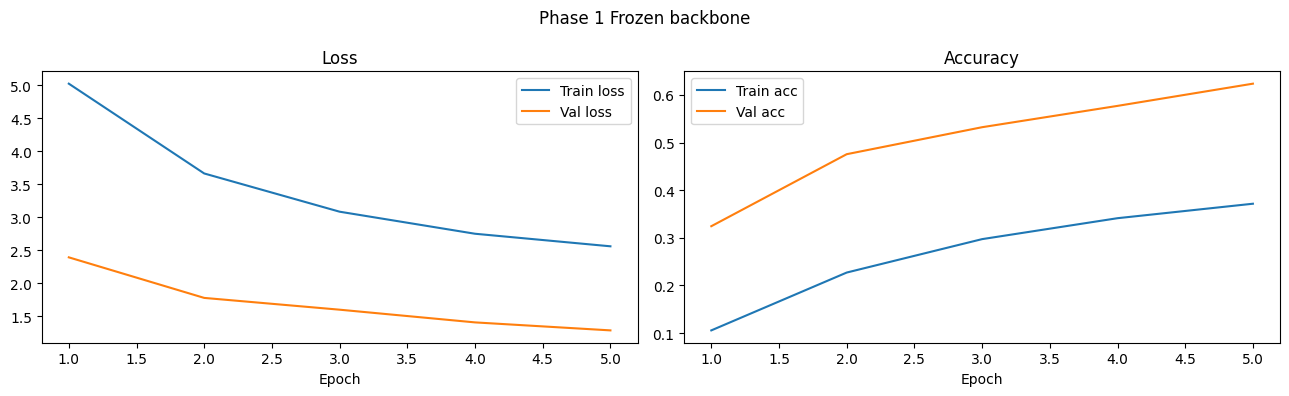

In [11]:
criterion = FocalLoss(gamma=2.0, label_smoothing=0.1, num_classes=NUM_CLASSES)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-2, weight_decay=1e-4)

PHASE1_EPOCHS = 5
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=1e-2,
    epochs=PHASE1_EPOCHS, steps_per_epoch=len(train_dl),
    pct_start=0.2, anneal_strategy='cos')
scaler = torch.cuda.amp.GradScaler()

log_p1 = []; best_val_acc = 0.0
print('=== PHASE 1 — Frozen backbone ===')
for epoch in range(1, PHASE1_EPOCHS + 1):
    tr_loss, tr_acc       = train_one_epoch(model, train_dl, criterion, optimizer, scaler, use_mixup=False)
    vl_loss, vl_acc, _, _ = evaluate(model, val_dl, criterion)
    lr_now = optimizer.param_groups[0]['lr']
    log_p1.append(dict(epoch=epoch, train_loss=tr_loss, train_acc=tr_acc,
                       val_loss=vl_loss, val_acc=vl_acc, lr=lr_now))
    print(f'  Ep {epoch}/{PHASE1_EPOCHS}  train_acc={tr_acc:.4f}  val_acc={vl_acc:.4f}  lr={lr_now:.2e}')
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), MODEL_DIR / 'best_phase1.pth')
        print('    ✓ Saved')

pd.DataFrame(log_p1).to_csv(OUTPUT_DIR / 'log_phase1.csv', index=False)
plot_curves(log_p1, 'Phase 1 Frozen backbone')

## 11. Phase 2 — Full Fine-Tune with Mixup

Trainable params Phase 2: 117,266,297
=== PHASE 2 — Full fine-tune with Mixup ===


  train:   0%|          | 0/932 [00:00<?, ?it/s]

  eval:   0%|          | 0/100 [00:00<?, ?it/s]

  Ep 1/20  train_acc=0.2639  val_acc=0.7630  lr=2.85e-05
    ✓ Saved  (best=0.7630)


  train:   0%|          | 0/932 [00:00<?, ?it/s]

...

  eval:   0%|          | 0/100 [00:00<?, ?it/s]

  Ep 19/20  train_acc=0.4962  val_acc=0.8685  lr=1.58e-06


  train:   0%|          | 0/932 [00:00<?, ?it/s]

  eval:   0%|          | 0/100 [00:00<?, ?it/s]

  Ep 20/20  train_acc=0.4899  val_acc=0.8710  lr=4.75e-07


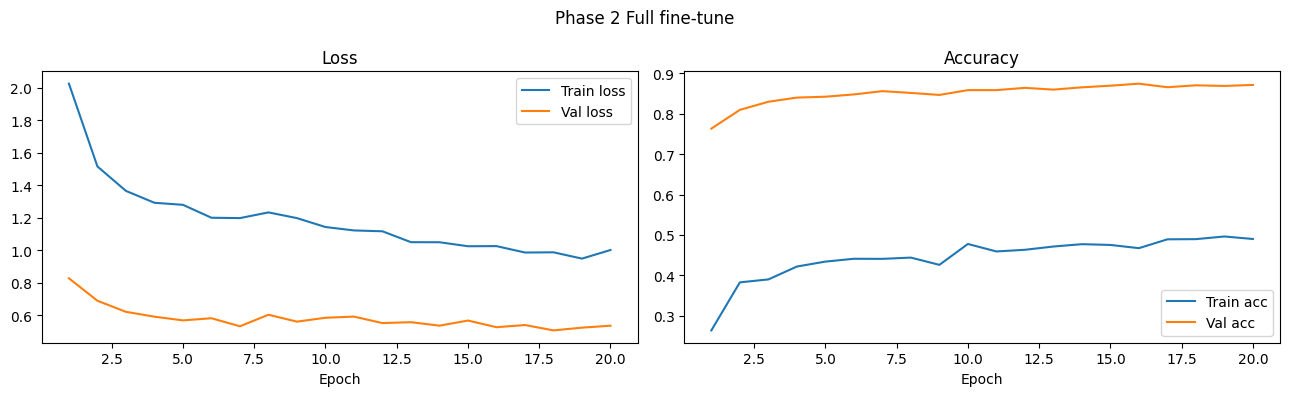

In [12]:
for param in model.parameters():
    param.requires_grad = True

print(f'Trainable params Phase 2: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

backbone_params   = [p for n,p in model.named_parameters() if 'classifier' not in n]
classifier_params = [p for n,p in model.named_parameters() if 'classifier'     in n]

optimizer2 = optim.AdamW([
    {'params': backbone_params,   'lr': 3e-5},
    {'params': classifier_params, 'lr': 3e-4},
], weight_decay=1e-4)

PHASE2_EPOCHS = 20
scheduler2 = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer2, T_0=7, T_mult=2, eta_min=1e-7)
scaler2 = torch.cuda.amp.GradScaler()

model.load_state_dict(torch.load(MODEL_DIR / 'best_phase1.pth', map_location=DEVICE))

log_p2 = []; best_val_acc2 = 0.0; patience = 0; MAX_PATIENCE = 7

print('=== PHASE 2 — Full fine-tune with Mixup ===')
for epoch in range(1, PHASE2_EPOCHS + 1):
    tr_loss, tr_acc       = train_one_epoch(model, train_dl, criterion, optimizer2, scaler2, use_mixup=True)
    vl_loss, vl_acc, _, _ = evaluate(model, val_dl, criterion)
    scheduler2.step(epoch)
    lr_now = optimizer2.param_groups[0]['lr']
    log_p2.append(dict(epoch=epoch, train_loss=tr_loss, train_acc=tr_acc,
                       val_loss=vl_loss, val_acc=vl_acc, lr=lr_now))
    print(f'  Ep {epoch}/{PHASE2_EPOCHS}  train_acc={tr_acc:.4f}  val_acc={vl_acc:.4f}  lr={lr_now:.2e}')
    if vl_acc > best_val_acc2:
        best_val_acc2 = vl_acc; patience = 0
        torch.save(model.state_dict(), MODEL_DIR / 'best_phase2.pth')
        print(f'    ✓ Saved  (best={best_val_acc2:.4f})')
    else:
        patience += 1
        if patience >= MAX_PATIENCE:
            print(f'  Early stopping at epoch {epoch}'); break

pd.DataFrame(log_p2).to_csv(OUTPUT_DIR / 'log_phase2.csv', index=False)
plot_curves(log_p2, 'Phase 2 Full fine-tune')

## 12. Phase 3 — Polish (no Mixup)

=== PHASE 3 — Polish (no Mixup) ===


  train:   0%|          | 0/932 [00:00<?, ?it/s]

  eval:   0%|          | 0/100 [00:00<?, ?it/s]

  Ep 1/5  train_acc=0.9080  val_acc=0.8676  lr=4.52e-06
    ✓ Saved  (best=0.8676)


  train:   0%|          | 0/932 [00:00<?, ?it/s]

...

  eval:   0%|          | 0/100 [00:00<?, ?it/s]

  Ep 4/5  train_acc=0.9166  val_acc=0.8748  lr=4.87e-07
    ✓ Saved  (best=0.8748)


  train:   0%|          | 0/932 [00:00<?, ?it/s]

  eval:   0%|          | 0/100 [00:00<?, ?it/s]

  Ep 5/5  train_acc=0.9192  val_acc=0.8741  lr=1.00e-08


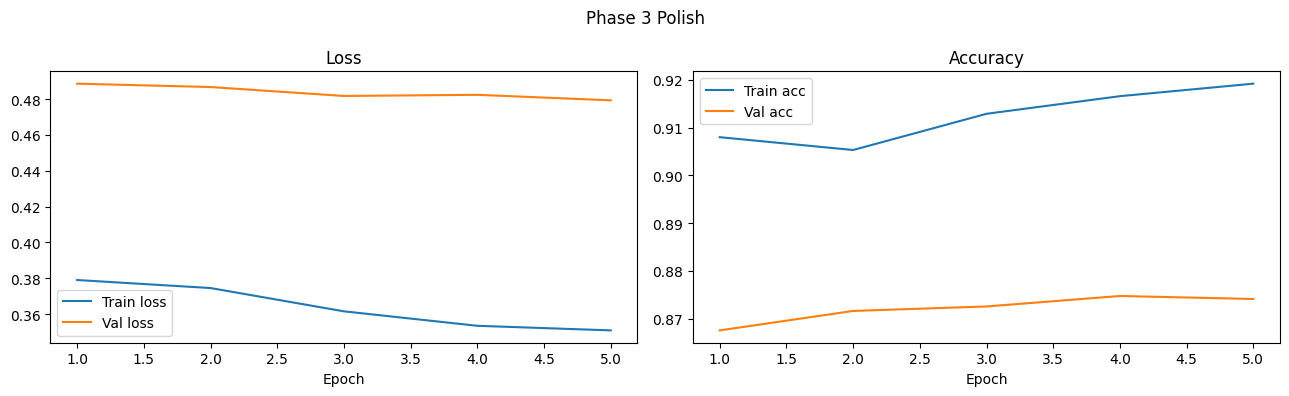

In [13]:
model.load_state_dict(torch.load(MODEL_DIR / 'best_phase2.pth', map_location=DEVICE))

optimizer3 = optim.AdamW([
    {'params': backbone_params,   'lr': 5e-6},
    {'params': classifier_params, 'lr': 5e-5},
], weight_decay=1e-4)

PHASE3_EPOCHS = 5
scheduler3 = optim.lr_scheduler.CosineAnnealingLR(optimizer3, T_max=PHASE3_EPOCHS, eta_min=1e-8)
scaler3    = torch.cuda.amp.GradScaler()

log_p3 = []; best_val_acc3 = 0.0
print('=== PHASE 3 — Polish (no Mixup) ===')
for epoch in range(1, PHASE3_EPOCHS + 1):
    tr_loss, tr_acc       = train_one_epoch(model, train_dl, criterion, optimizer3, scaler3, use_mixup=False)
    vl_loss, vl_acc, _, _ = evaluate(model, val_dl, criterion)
    scheduler3.step()
    lr_now = optimizer3.param_groups[0]['lr']
    log_p3.append(dict(epoch=epoch, train_loss=tr_loss, train_acc=tr_acc,
                       val_loss=vl_loss, val_acc=vl_acc, lr=lr_now))
    print(f'  Ep {epoch}/{PHASE3_EPOCHS}  train_acc={tr_acc:.4f}  val_acc={vl_acc:.4f}  lr={lr_now:.2e}')
    if vl_acc > best_val_acc3:
        best_val_acc3 = vl_acc
        torch.save(model.state_dict(), MODEL_DIR / 'best_phase3.pth')
        print(f'    ✓ Saved  (best={best_val_acc3:.4f})')

pd.DataFrame(log_p3).to_csv(OUTPUT_DIR / 'log_phase3.csv', index=False)
plot_curves(log_p3, 'Phase 3 Polish')

## 13. Test Evaluation — Standard + TTA

In [14]:
model.load_state_dict(torch.load(MODEL_DIR / 'best_phase3.pth', map_location=DEVICE))

_, test_acc_std, preds_std, labels_true = evaluate(model, test_dl, criterion)
print(f'Test Accuracy (standard) : {test_acc_std:.4f}  ({test_acc_std*100:.2f}%)')

print('\nRunning TTA (5 views)...')
test_acc_tta, preds_tta = evaluate_tta(model, X_test, y_test)
print(f'Test Accuracy (TTA)      : {test_acc_tta:.4f}  ({test_acc_tta*100:.2f}%)')

# Use TTA predictions for final report
preds      = preds_tta
test_acc   = test_acc_tta
labels_true = y_test.tolist()

class_names_display = [c.replace('_',' ').title() for c in classes]
print('\n' + classification_report(labels_true, preds, target_names=class_names_display))

  eval:   0%|          | 0/100 [00:00<?, ?it/s]

Test Accuracy (standard) : 0.8713  (87.13%)

Running TTA (5 views)...


  TTA:   0%|          | 0/100 [00:00<?, ?it/s]

  TTA:   0%|          | 0/100 [00:00<?, ?it/s]

  TTA:   0%|          | 0/100 [00:00<?, ?it/s]

  TTA:   0%|          | 0/100 [00:00<?, ?it/s]

  TTA:   0%|          | 0/100 [00:00<?, ?it/s]

Test Accuracy (TTA)      : 0.8738  (87.38%)

                                              precision    recall  f1-score   support

                          Banded Kukri Snake       0.96      0.96      0.96       137
                    Black Headed Royal Snake       0.77      0.80      0.78        79
                           Blunt Nosed Viper       0.96      0.94      0.95        77
                        Brahminy Blind Snake       0.96      1.00      0.98       361
                       Buff Striped Keelback       0.94      0.95      0.94       295
                               Caspian Cobra       0.93      0.89      0.91        83
                          Checkered Keelback       0.89      0.91      0.90       184
                            Common Cat Snake       0.89      0.98      0.93        86
                                Common Krait       0.94      0.92      0.93       262
                             Common Sand Boa       0.95      0.94      0.95       193
        

## 14. Confusion Matrix

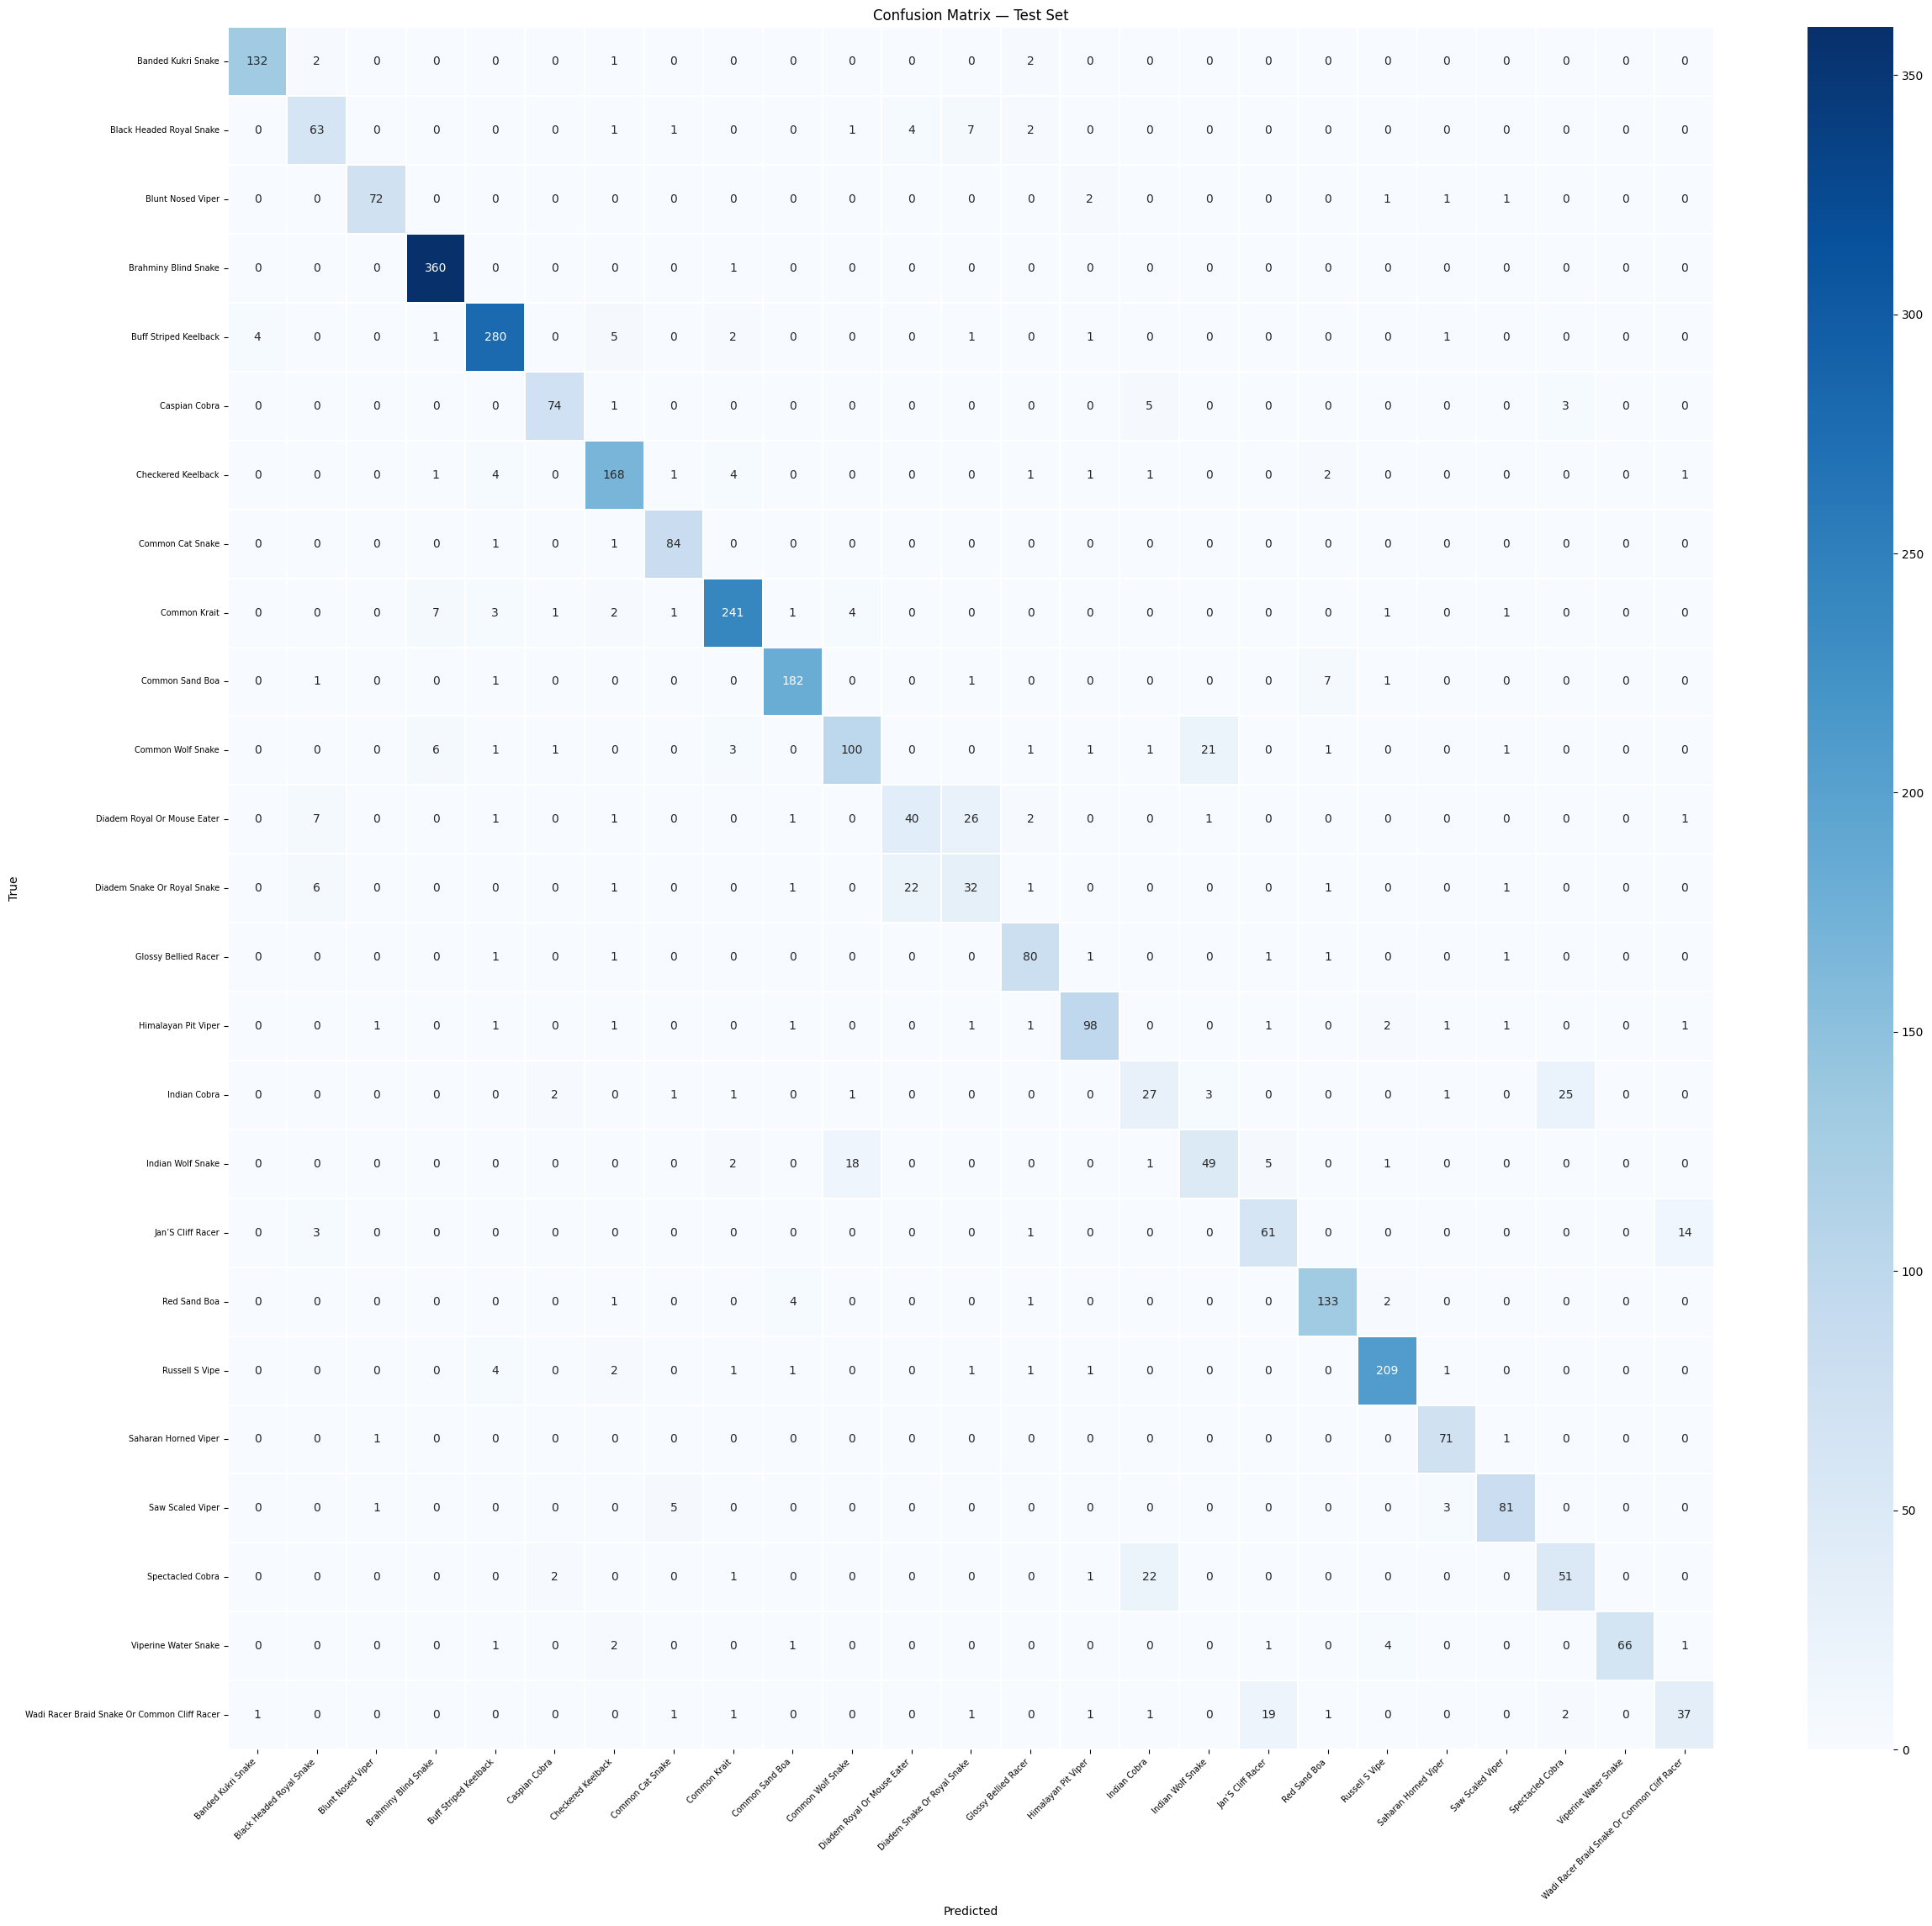

In [15]:
cm = confusion_matrix(labels_true, preds)
fig, ax = plt.subplots(figsize=(max(10, NUM_CLASSES), max(8, NUM_CLASSES - 2)))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names_display, yticklabels=class_names_display,
            cmap='Blues', ax=ax, linewidths=0.3)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion Matrix — Test Set')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=150)
plt.show()

## 15. Per-Class F1

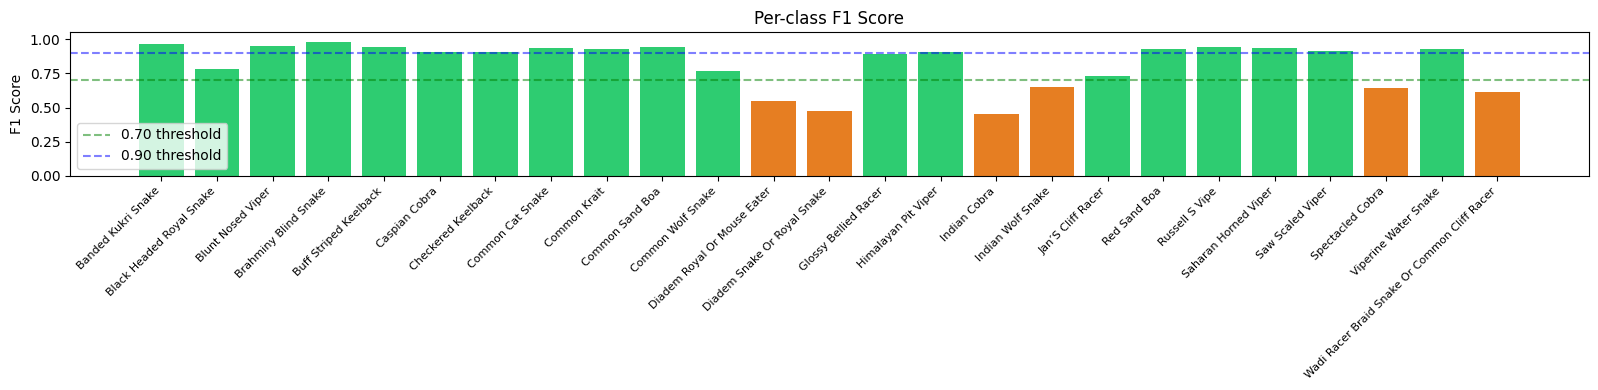

In [16]:
f1_per_class = f1_score(labels_true, preds, average=None)
fig, ax = plt.subplots(figsize=(16, 4))
colors = ['#2ecc71' if f>=0.7 else '#e67e22' if f>=0.4 else '#e74c3c' for f in f1_per_class]
ax.bar(range(NUM_CLASSES), f1_per_class, color=colors)
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels(class_names_display, rotation=45, ha='right', fontsize=8)
ax.axhline(0.7, color='green', linestyle='--', alpha=0.5, label='0.70 threshold')
ax.axhline(0.9, color='blue',  linestyle='--', alpha=0.5, label='0.90 threshold')
ax.set_ylabel('F1 Score'); ax.set_title('Per-class F1 Score')
ax.set_ylim(0, 1.05); ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'per_class_f1.png', dpi=150)
plt.show()

## 16. Grad-CAM Visualisation

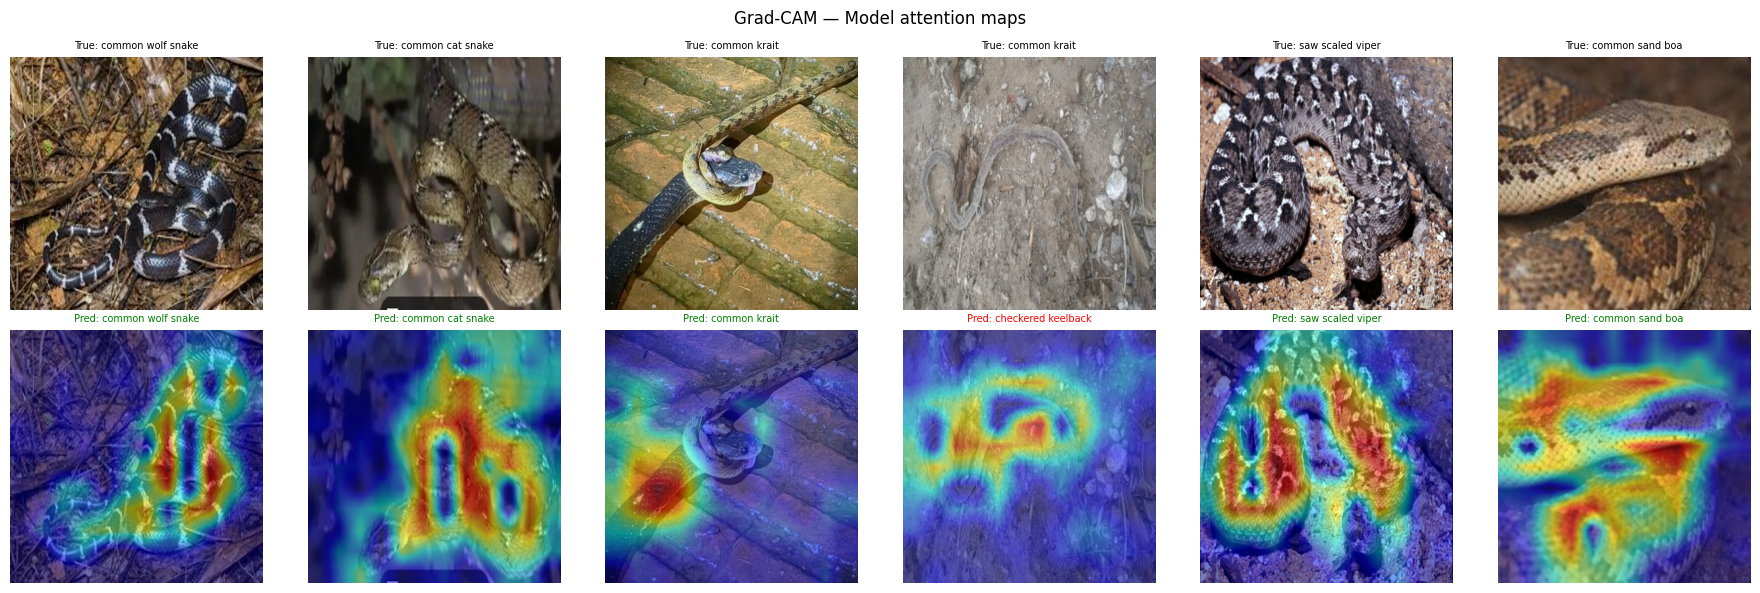

In [17]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

target_layers = [model.blocks[-1][-1]]
cam = GradCAM(model=model, target_layers=target_layers)

sample_indices = random.sample(range(len(X_test)), min(6, len(X_test)))
fig, axes = plt.subplots(2, len(sample_indices), figsize=(3*len(sample_indices), 6))

for col, idx in enumerate(sample_indices):
    img_pil  = Image.open(X_test[idx]).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    img_np   = np.array(img_pil) / 255.0
    inp      = val_tf(img_pil).unsqueeze(0).to(DEVICE)
    true_cls = IDX_TO_CLASS[int(y_test[idx])]
    with torch.no_grad():
        pred_idx = model(inp).argmax(1).item()
    pred_cls = IDX_TO_CLASS[pred_idx]
    grayscale_cam = cam(input_tensor=inp, targets=[ClassifierOutputTarget(pred_idx)])
    cam_img = show_cam_on_image(img_np.astype(np.float32), grayscale_cam[0], use_rgb=True)
    axes[0,col].imshow(img_pil); axes[0,col].axis('off')
    axes[0,col].set_title(f"True: {true_cls.replace('_',' ')}", fontsize=7)
    axes[1,col].imshow(cam_img); axes[1,col].axis('off')
    axes[1,col].set_title(f"Pred: {pred_cls.replace('_',' ')}", fontsize=7,
                           color='green' if pred_cls==true_cls else 'red')

plt.suptitle('Grad-CAM — Model attention maps', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'gradcam.png', dpi=150)
plt.show()

## 17. Save Final Checkpoint

In [18]:
checkpoint = {
    'model_state_dict': model.state_dict(),
    'class_to_idx'    : CLASS_TO_IDX,
    'idx_to_class'    : IDX_TO_CLASS,
    'num_classes'     : NUM_CLASSES,
    'img_size'        : IMG_SIZE,
    'architecture'    : MODEL_NAME,
    'test_accuracy'   : test_acc,
}
torch.save(checkpoint, MODEL_DIR / 'snake_classifier_final.pth')

with open(MODEL_DIR / 'class_mapping.json', 'w') as f:
    json.dump({'class_to_idx': CLASS_TO_IDX,
               'idx_to_class': {str(k):v for k,v in IDX_TO_CLASS.items()}}, f, indent=2)

print(f'✓ Model saved   → {MODEL_DIR}/snake_classifier_final.pth')
print(f'✓ Mapping saved → {MODEL_DIR}/class_mapping.json')
print(f'\n{"="*50}')
print(f'  FINAL TEST ACCURACY (TTA) : {test_acc*100:.2f}%')
print(f'  Number of classes         : {NUM_CLASSES}')
print(f'{"="*50}')

✓ Model saved   → /kaggle/working/models/snake_classifier_final.pth
✓ Mapping saved → /kaggle/working/models/class_mapping.json

  FINAL TEST ACCURACY (TTA) : 87.38%
  Number of classes         : 25


## 18. Inference Helper

Running inference on: /kaggle/input/datasets/abdullahkhaliq14/snakes-datasets/saw-scaled_viper-20260517T125539Z-3-001/saw-scaled_viper/saw-scaled_viper_444.jpg


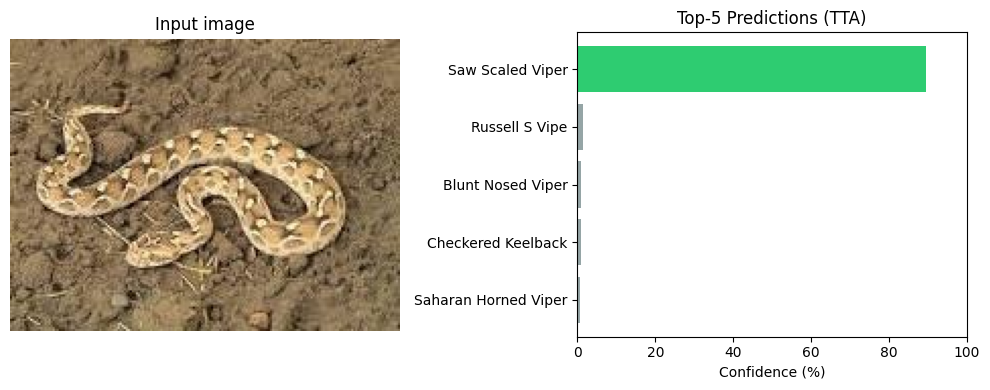

  #1  Saw Scaled Viper                               89.5%
  #2  Russell S Vipe                                 1.4%
  #3  Blunt Nosed Viper                              0.9%
  #4  Checkered Keelback                             0.8%
  #5  Saharan Horned Viper                           0.6%

All done! ✓


In [19]:
def predict_snake(image_path, checkpoint_path=None, use_tta=True):
    if checkpoint_path is not None:
        ckpt = torch.load(checkpoint_path, map_location=DEVICE)
        m = timm.create_model(ckpt['architecture'], pretrained=False,
                               num_classes=ckpt['num_classes'], drop_rate=0.3)
        m.load_state_dict(ckpt['model_state_dict'])
        idx_to_cls = ckpt['idx_to_class']
    else:
        m = model
        idx_to_cls = IDX_TO_CLASS

    m.eval().to(DEVICE)
    img = Image.open(image_path).convert('RGB')

    if use_tta:
        probs = torch.stack([
            torch.softmax(m(tf(img).unsqueeze(0).to(DEVICE)), dim=1).cpu()
            for tf in tta_tfs
        ]).mean(0)[0]
    else:
        inp   = val_tf(img).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            probs = torch.softmax(m(inp), dim=1)[0].cpu()

    top5 = probs.topk(5)
    results = [{'rank': i+1,
                'species': idx_to_cls[idx.item()].replace('_',' ').title(),
                'confidence': f'{prob.item()*100:.1f}%'}
               for i,(prob,idx) in enumerate(zip(top5.values, top5.indices))]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(img); axes[0].axis('off'); axes[0].set_title('Input image')
    species = [r['species'][:30] for r in results]
    confs   = [float(r['confidence'].strip('%')) for r in results]
    colors  = ['#2ecc71' if i==0 else '#95a5a6' for i in range(5)]
    axes[1].barh(species[::-1], confs[::-1], color=colors[::-1])
    axes[1].set_xlabel('Confidence (%)'); axes[1].set_title('Top-5 Predictions (TTA)')
    axes[1].set_xlim(0, 100)
    plt.tight_layout(); plt.show()
    return results


# Demo on a random test image
demo_img = str(X_test[random.randint(0, len(X_test)-1)])
print(f'Running inference on: {demo_img}')
results = predict_snake(demo_img)
for r in results:
    print(f"  #{r['rank']}  {r['species']:<45s}  {r['confidence']}")
print('\nAll done! ✓')